In [1]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict , Annotated
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq
import os 


In [2]:
load_dotenv()

True

In [3]:
# set up llm 
model = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv('GROQ_API_KEY')
)


In [4]:
class jokeState(TypedDict):
    topic : str
    joke:str
    explanation:str

In [5]:
def create_joke(state:jokeState):
    prompt = f'create a joke on a following topic: {state["topic"]}'
    res = model.invoke(prompt)
    return {
        'joke' : res
    }

In [11]:
def explain_joke(state:jokeState):
    prompt = f'explain the  joke:  "{state["joke"]}" on the topic:  "{state["topic"]}"'
    res = model.invoke(prompt)
    return {
        'explanation':res
    }

In [12]:
#create graph
graph = StateGraph(jokeState)


# add node
graph.add_node('create_joke',create_joke)
graph.add_node('explain_joke',explain_joke)


# add edges
graph.add_edge(START,'create_joke')
graph.add_edge('create_joke','explain_joke')
graph.add_edge('explain_joke',END)
 
checkpointer = InMemorySaver() # object of inmemorysaver to store the state 

# workflow 
workflow = graph.compile(checkpointer=checkpointer)


In [17]:
initial_state = {
    'topic' : 'pakistan cricket team'
}
config = {'configurable':{'thread_id': "1"}}
res = workflow.invoke(initial_state, config=config)


In [18]:
res

{'topic': 'pakistan cricket team',
 'joke': AIMessage(content='Why did the Pakistan cricket team go to the doctor?\n\nBecause they were feeling a little "Bowled" over by their recent performances and needed a "Six"-sense check-up!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 46, 'total_tokens': 83, 'completion_time': 0.090564076, 'completion_tokens_details': None, 'prompt_time': 0.009052979, 'prompt_tokens_details': None, 'queue_time': 0.00781689, 'total_time': 0.099617055}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ec078-7217-7353-94bc-37810515e3bb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 37, 'total_tokens': 83}),
 'explanation': AIMessage(content='The joke is a play on words related to cricket, which is a popular sport in Pakista

In [26]:
workflow.get_state(config=config)

StateSnapshot(values={'topic': 'pakistan cricket team', 'joke': AIMessage(content='Why did the Pakistan cricket team go to the doctor?\n\nBecause they were feeling a little "Bowled" over by their recent performances and needed a "Six"-sense check-up!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 46, 'total_tokens': 83, 'completion_time': 0.090564076, 'completion_tokens_details': None, 'prompt_time': 0.009052979, 'prompt_tokens_details': None, 'queue_time': 0.00781689, 'total_time': 0.099617055}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ec078-7217-7353-94bc-37810515e3bb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 37, 'total_tokens': 83}), 'explanation': AIMessage(content='The joke is a play on words related to cricket, which is a popul

In [28]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'pakistan cricket team', 'joke': AIMessage(content='Why did the Pakistan cricket team go to the doctor?\n\nBecause they were feeling a little "Bowled" over by their recent performances and needed a "Six"-sense check-up!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 46, 'total_tokens': 83, 'completion_time': 0.090564076, 'completion_tokens_details': None, 'prompt_time': 0.009052979, 'prompt_tokens_details': None, 'queue_time': 0.00781689, 'total_time': 0.099617055}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ec078-7217-7353-94bc-37810515e3bb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 37, 'total_tokens': 83}), 'explanation': AIMessage(content='The joke is a play on words related to cricket, which is a popu

In [30]:
initial_state = {
    'topic' : 'indian air force'
}
config2 = {'configurable':{'thread_id': "2"}}
res = workflow.invoke(initial_state, config=config2)


In [32]:
workflow.get_state(config=config2)

StateSnapshot(values={'topic': 'indian air force', 'joke': AIMessage(content='Why did the Indian Air Force pilot break up with his girlfriend?\n\nBecause he wanted to fly solo, but she was always trying to ground him.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 46, 'total_tokens': 76, 'completion_time': 0.034146946, 'completion_tokens_details': None, 'prompt_time': 0.003468734, 'prompt_tokens_details': None, 'queue_time': 0.036465404, 'total_time': 0.03761568}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ec080-dbea-79b1-9356-bf47073ce7d6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 30, 'total_tokens': 76}), 'explanation': AIMessage(content='The joke is a play on words, using a common phrase from aviation (flying solo) and a common phras

In [34]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'indian air force', 'joke': AIMessage(content='Why did the Indian Air Force pilot break up with his girlfriend?\n\nBecause he wanted to fly solo, but she was always trying to ground him.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 46, 'total_tokens': 76, 'completion_time': 0.034146946, 'completion_tokens_details': None, 'prompt_time': 0.003468734, 'prompt_tokens_details': None, 'queue_time': 0.036465404, 'total_time': 0.03761568}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ec080-dbea-79b1-9356-bf47073ce7d6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 30, 'total_tokens': 76}), 'explanation': AIMessage(content='The joke is a play on words, using a common phrase from aviation (flying solo) and a common phra

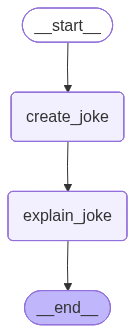

In [29]:
workflow